<a href="https://colab.research.google.com/github/elektra773/Final-Project-ECON23050/blob/main/patent_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

DATA_DIR = Path("/content/drive/MyDrive/FinalProject")
OUT_DIR = Path("/content/outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Chunk 2: Keyword dictionaries and regex patterns
This chunk defines the AI terms, therapeutic-area terms, and biological target terms the notebook will search for in patent text. I expanded the AI and target vocabularies and changed the area setup so we can score all areas instead of assigning the first match.

In [2]:
AI_KEYWORDS = [
    "machine learning",
    "deep learning",
    "neural network",
    "neural net",
    "artificial intelligence",
    "random forest",
    "support vector machine",
    "support vector machines",
    "svm",
    "classifier",
    "classification model",
    "predictive model",
    "prediction model",
    "trained model",
    "training data",
    "feature selection",
    "feature extraction",
    "supervised learning",
    "unsupervised learning",
    "reinforcement learning",
    "computer implemented model",
    "computer-implemented model",
    "algorithmic model",
    "data-driven model",
]

THERAPEUTIC_AREA_KEYWORDS = {
    "oncology": [
        "cancer", "tumor", "tumour", "carcinoma", "oncology", "neoplasm",
        "leukemia", "lymphoma", "melanoma", "sarcoma", "metastatic",
        "malignancy", "solid tumor", "solid tumour", "antitumor", "anti-tumor",
        "anti cancer", "anti-cancer"
    ],
    "neurology": [
        "alzheimer", "parkinson", "neurolog", "neurodegenerative", "epilepsy",
        "multiple sclerosis", "dementia", "cns", "central nervous system",
        "seizure", "huntington", "amyotrophic lateral sclerosis", "als"
    ],
    "cardiovascular": [
        "heart", "cardiac", "cardiovascular", "hypertension", "atherosclerosis",
        "arrhythmia", "myocardial", "vascular", "thrombosis", "ischemia",
        "heart failure", "coronary", "blood pressure"
    ],
    "immunology": [
        "immune", "immunology", "immunotherapy", "autoimmune", "cytokine",
        "inflammation", "inflammatory", "antibody", "t cell", "b cell",
        "checkpoint inhibitor", "immune response", "immunomodulatory"
    ],
    "infectious_disease": [
        "infection", "infectious", "antiviral", "antibiotic", "bacterial",
        "viral", "fungal", "pathogen", "sepsis", "microbial", "antimicrobial",
        "hiv", "influenza", "coronavirus", "sars-cov", "hepatitis"
    ],
    "metabolic_disorders": [
        "diabetes", "metabolic", "obesity", "insulin", "hyperglycemia",
        "dyslipidemia", "cholesterol", "lipid", "fatty liver", "nash",
        "metabolic syndrome", "glucose", "hyperlipidemia"
    ],
}

MECHANISM_KEYWORDS = {
    "oncology": [
        "kinase inhibitor", "oncogene", "tumor suppressor", "cell proliferation",
        "apoptosis", "metastasis", "antiproliferative", "anti-proliferative",
        "dna damage response", "synthetic lethality"
    ],
    "neurology": [
        "neuroprotective", "synaptic", "neuron", "neuronal", "neurotransmitter",
        "blood brain barrier", "amyloid", "tau phosphorylation", "dopaminergic"
    ],
    "cardiovascular": [
        "angiogenesis", "vascular tone", "platelet aggregation", "cardiac hypertrophy",
        "vasodilation", "endothelial dysfunction", "antithrombotic"
    ],
    "immunology": [
        "immune modulation", "immune checkpoint", "cytokine signaling",
        "t cell activation", "antigen presentation", "inflammatory signaling",
        "adaptive immunity", "innate immunity"
    ],
    "infectious_disease": [
        "antimicrobial activity", "viral replication", "bacterial growth",
        "pathogen load", "host-pathogen", "anti infective", "anti-infective"
    ],
    "metabolic_disorders": [
        "glucose homeostasis", "insulin sensitivity", "lipid metabolism",
        "energy balance", "metabolic regulation"
    ],
}

GENERAL_THERAPEUTIC_KEYWORDS = [
    "pharmaceutical composition",
    "pharmaceutical formulation",
    "therapeutic composition",
    "therapeutic agent",
    "drug delivery",
    "pharmaceutically acceptable",
    "compound useful for treating",
    "method for treating",
    "treatment of a disease",
    "treatment of a disorder",
    "therapy for",
    "therapeutic use",
]

TARGET_KEYWORDS = {
    "EGFR": [r"\begfr\b", r"\berbb1\b", r"\bepidermal growth factor receptor\b"],
    "ERBB2": [r"\berbb2\b", r"\bher2\b", r"\bhuman epidermal growth factor receptor 2\b"],
    "HER3": [r"\bher3\b", r"\berbb3\b"],
    "KRAS": [r"\bkras\b"],
    "NRAS": [r"\bnras\b"],
    "HRAS": [r"\bhras\b"],
    "BRAF": [r"\bbraf\b"],
    "RAF1": [r"\braf1\b", r"\bc-raf\b"],
    "MEK": [r"\bmek1\b", r"\bmek2\b", r"\bmap2k1\b", r"\bmap2k2\b", r"\bmek\b"],
    "ERK": [r"\berk1\b", r"\berk2\b", r"\bmapk1\b", r"\bmapk3\b", r"\berk\b"],
    "PIK3CA": [r"\bpik3ca\b", r"\bpi3k\b", r"\bphosphoinositide 3-kinase\b"],
    "AKT": [r"\bakt1\b", r"\bakt2\b", r"\bakt3\b", r"\bakt\b"],
    "MTOR": [r"\bmtor\b", r"\bmammalian target of rapamycin\b"],
    "PTEN": [r"\bpten\b"],
    "TP53": [r"\btp53\b", r"\bp53\b"],
    "BRCA": [r"\bbrca1\b", r"\bbrca2\b", r"\bbreast cancer gene\b"],
    "PARP": [r"\bparp1\b", r"\bparp2\b", r"\bparp\b", r"\bpoly\(adp-ribose\) polymerase\b"],
    "VEGF": [r"\bvegf\b", r"\bvegfa\b", r"\bvascular endothelial growth factor\b"],
    "VEGFR": [r"\bvegfr\b", r"\bvegfr1\b", r"\bvegfr2\b", r"\bflt1\b", r"\bkdr\b"],
    "PDCD1": [r"\bpdcd1\b", r"\bpd-?1\b", r"\bprogrammed cell death protein 1\b"],
    "CD274": [r"\bcd274\b", r"\bpd-?l1\b", r"\bprogrammed death ligand 1\b"],
    "CTLA4": [r"\bctla-?4\b", r"\bctla4\b"],
    "TNF": [r"\btnf\b", r"\btumou?r necrosis factor\b"],
    "IL6": [r"\bil-?6\b", r"\binterleukin-?6\b"],
    "IL1B": [r"\bil-?1b\b", r"\bil1b\b", r"\binterleukin-?1 beta\b"],
    "JAK": [r"\bjak1\b", r"\bjak2\b", r"\bjak3\b", r"\btyk2\b", r"\bjak\b"],
    "STAT3": [r"\bstat3\b"],
    "NFKB": [r"\bnf-?kb\b", r"\bnuclear factor kappa b\b"],
    "TGFB": [r"\btgf-?\s?beta\b", r"\btransforming growth factor beta\b", r"\btgfb\b"],
    "IFNG": [r"\bifn-?\s?gamma\b", r"\binterferon gamma\b", r"\bifng\b"],
    "CD19": [r"\bcd19\b"],
    "BCMA": [r"\bbcma\b", r"\btnfrsf17\b"],
    "DLL3": [r"\bdll3\b"],
    "ALK": [r"\balk\b", r"\banaplastic lymphoma kinase\b"],
    "ROS1": [r"\bros1\b"],
    "RET": [r"\bret\b"],
    "FGFR": [r"\bfgfr1\b", r"\bfgfr2\b", r"\bfgfr3\b", r"\bfgfr4\b", r"\bfgfr\b"],
    "KIT": [r"\bkit\b", r"\bc-kit\b", r"\bcd117\b"],
    "FLT3": [r"\bflt3\b"],
    "BTK": [r"\bbtk\b", r"\bbruton'?s tyrosine kinase\b"],
    "BCL2": [r"\bbcl2\b", r"\bb-cell lymphoma 2\b"],
    "MCL1": [r"\bmcl1\b"],
    "CDK4_6": [r"\bcdk4\b", r"\bcdk6\b", r"\bcyclin-dependent kinase 4\b", r"\bcyclin-dependent kinase 6\b"],
    "HSP90": [r"\bhsp90\b"],
    "PROTEASOME": [r"\bproteasome\b", r"\bproteasomal\b"],
    "PCSK9": [r"\bpcsk9\b"],
    "SGLT2": [r"\bsglt2\b", r"\bslc5a2\b"],
    "DPP4": [r"\bdpp-?4\b", r"\bdipeptidyl peptidase-?4\b"],
    "GLP1R": [r"\bglp-?1r\b", r"\bglucagon-like peptide 1 receptor\b"],
    "PPARG": [r"\bpparg\b", r"\bperoxisome proliferator-activated receptor gamma\b"],
    "BACE1": [r"\bbace1\b", r"\bbeta-secretase 1\b"],
    "MAPT": [r"\bmapt\b", r"\btau\b"],
    "SNCA": [r"\bsnca\b", r"\balpha-synuclein\b"],
    "LRRK2": [r"\blrrk2\b"],
}

TARGET_TO_AREA = {
    "EGFR": {"oncology": 3},
    "ERBB2": {"oncology": 3},
    "HER3": {"oncology": 2},
    "KRAS": {"oncology": 3},
    "NRAS": {"oncology": 3},
    "HRAS": {"oncology": 2},
    "BRAF": {"oncology": 3},
    "RAF1": {"oncology": 2},
    "MEK": {"oncology": 2},
    "ERK": {"oncology": 2},
    "PIK3CA": {"oncology": 2},
    "AKT": {"oncology": 2},
    "MTOR": {"oncology": 2, "metabolic_disorders": 1},
    "PTEN": {"oncology": 2},
    "TP53": {"oncology": 3},
    "BRCA": {"oncology": 3},
    "PARP": {"oncology": 3},
    "VEGF": {"oncology": 2, "cardiovascular": 1},
    "VEGFR": {"oncology": 2, "cardiovascular": 1},
    "PDCD1": {"immunology": 2, "oncology": 2},
    "CD274": {"immunology": 2, "oncology": 2},
    "CTLA4": {"immunology": 2, "oncology": 2},
    "TNF": {"immunology": 3},
    "IL6": {"immunology": 3},
    "IL1B": {"immunology": 3},
    "JAK": {"immunology": 2},
    "STAT3": {"immunology": 1, "oncology": 1},
    "NFKB": {"immunology": 2},
    "TGFB": {"oncology": 1, "immunology": 1},
    "IFNG": {"immunology": 2},
    "CD19": {"oncology": 2, "immunology": 1},
    "BCMA": {"oncology": 2, "immunology": 1},
    "DLL3": {"oncology": 2},
    "ALK": {"oncology": 3},
    "ROS1": {"oncology": 3},
    "RET": {"oncology": 3},
    "FGFR": {"oncology": 2},
    "KIT": {"oncology": 2},
    "FLT3": {"oncology": 2},
    "BTK": {"oncology": 2, "immunology": 1},
    "BCL2": {"oncology": 2},
    "MCL1": {"oncology": 2},
    "CDK4_6": {"oncology": 2},
    "HSP90": {"oncology": 1},
    "PROTEASOME": {"oncology": 1},
    "PCSK9": {"cardiovascular": 3},
    "SGLT2": {"metabolic_disorders": 3},
    "DPP4": {"metabolic_disorders": 3},
    "GLP1R": {"metabolic_disorders": 3},
    "PPARG": {"metabolic_disorders": 2},
    "BACE1": {"neurology": 3},
    "MAPT": {"neurology": 3},
    "SNCA": {"neurology": 3},
    "LRRK2": {"neurology": 3},
}

AI_PATTERNS = [re.compile(rf"\b{re.escape(term)}\b", flags=re.IGNORECASE) for term in AI_KEYWORDS]

AREA_PATTERNS = {
    area: [re.compile(rf"\b{re.escape(term)}\b", flags=re.IGNORECASE) for term in terms]
    for area, terms in THERAPEUTIC_AREA_KEYWORDS.items()
}

MECHANISM_PATTERNS = {
    area: [re.compile(rf"\b{re.escape(term)}\b", flags=re.IGNORECASE) for term in terms]
    for area, terms in MECHANISM_KEYWORDS.items()
}

GENERAL_THERAPEUTIC_PATTERNS = [
    re.compile(rf"\b{re.escape(term)}\b", flags=re.IGNORECASE)
    for term in GENERAL_THERAPEUTIC_KEYWORDS
]

TARGET_PATTERNS = {
    target: re.compile("|".join(patterns), flags=re.IGNORECASE)
    for target, patterns in TARGET_KEYWORDS.items()
}




Chunk 3: Helper functions
This chunk loads large TSVs in chunks, normalizes patent text, assigns therapeutic areas by score rather than first match, detects AI language, and computes your concentration and entropy measures.

In [3]:
def load_filtered_tsv(path, usecols, ids_df, chunksize=250_000):
    parts = []
    total_rows = 0
    matched_rows = 0

    for i, chunk in enumerate(pd.read_csv(
        path,
        sep="\t",
        usecols=usecols,
        dtype="string",
        chunksize=chunksize,
        low_memory=False,
    ), start=1):
        total_rows += len(chunk)
        chunk = chunk.merge(ids_df, on="patent_id", how="inner")
        matched_rows += len(chunk)

        if not chunk.empty:
            parts.append(chunk)

        if i % 10 == 0:
            print(f"{path.name}: processed {total_rows:,} rows, kept {matched_rows:,}")

    out = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(columns=usecols)
    print(f"{path.name}: final shape = {out.shape}")
    return out


def normalize_text(series):
    return (
        series.fillna("")
        .astype(str)
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


def detect_ai(text):
    if not text:
        return 0
    return int(any(pattern.search(text) for pattern in AI_PATTERNS))


def classify_row(row, target_cols):
    text = row["text_for_analysis"]
    scores = {area: 0 for area in THERAPEUTIC_AREA_KEYWORDS}

    for area, patterns in AREA_PATTERNS.items():
        scores[area] += 2 * sum(bool(pattern.search(text)) for pattern in patterns)

    for area, patterns in MECHANISM_PATTERNS.items():
        scores[area] += sum(bool(pattern.search(text)) for pattern in patterns)

    for target in target_cols:
        if row[target] == 1 and target in TARGET_TO_AREA:
            for area, weight in TARGET_TO_AREA[target].items():
                scores[area] += weight

    best_area = max(scores, key=scores.get)
    if scores[best_area] > 0:
        return best_area

    if any(pattern.search(text) for pattern in GENERAL_THERAPEUTIC_PATTERNS):
        return "general_therapeutic"

    return "unclassified"


def compute_entropy(group):
    target_counts = group[list(TARGET_KEYWORDS)].sum(axis=0)
    total_mentions = float(target_counts.sum())
    if total_mentions == 0:
        return 0.0
    shares = target_counts[target_counts > 0] / total_mentions
    return float(-(shares * np.log(shares)).sum())


def compute_top4_share(group):
    firm_counts = (
        group.dropna(subset=["assignee_id"])
        .groupby("assignee_id")
        .size()
        .sort_values(ascending=False)
    )
    if firm_counts.empty:
        return 0.0
    return float(firm_counts.head(4).sum() / len(group))



Chunk 4: Identify pharmaceutical patents using CPC A61K
This chunk reads the huge CPC file in pieces and keeps only the patent IDs that belong to pharmaceutical patents.

In [4]:
CACHE_DIR = Path("/content/drive/MyDrive/FinalProject/cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

a61k_ids_path = CACHE_DIR / "a61k_ids.csv"

if a61k_ids_path.exists():
    a61k_df = pd.read_csv(a61k_ids_path, dtype="string", low_memory=False)
    print("Loaded cached A61K patent IDs:", a61k_df.shape[0])
else:
    a61k_ids = set()

    for chunk in pd.read_csv(
        DATA_DIR / "g_cpc_current.tsv",
        sep="\t",
        usecols=["patent_id", "cpc_subclass"],
        dtype={"patent_id": "string", "cpc_subclass": "string"},
        chunksize=1_000_000,
        low_memory=False,
    ):
        keep = chunk.loc[chunk["cpc_subclass"].str.upper() == "A61K", "patent_id"].dropna()
        a61k_ids.update(keep.tolist())

    a61k_df = pd.DataFrame({"patent_id": pd.Series(list(a61k_ids), dtype="string")})
    a61k_df.to_csv(a61k_ids_path, index=False)
    print("Built and cached A61K patent IDs:", a61k_df.shape[0])




Built and cached A61K patent IDs: 308048


Chunk 5: Load only the needed rows and columns from each input table
This chunk avoids crashing Colab by reading only the columns you need and only for the pharmaceutical patents you already identified. 5 min chunk

In [5]:
patent_cache = CACHE_DIR / "patent_filtered.csv"
application_cache = CACHE_DIR / "application_filtered.csv"
abstract_cache = CACHE_DIR / "abstract_filtered.csv"
assignee_cache = CACHE_DIR / "assignee_filtered.csv"

if all(path.exists() for path in [patent_cache, application_cache, abstract_cache, assignee_cache]):
    patent = pd.read_csv(patent_cache, dtype="string", low_memory=False)
    application = pd.read_csv(application_cache, dtype="string", low_memory=False)
    abstract = pd.read_csv(abstract_cache, dtype="string", low_memory=False)
    assignee = pd.read_csv(assignee_cache, dtype="string", low_memory=False)
    print("Loaded cached filtered tables.")
else:
    patent = load_filtered_tsv(
        DATA_DIR / "g_patent.tsv",
        ["patent_id", "patent_date", "patent_title"],
        a61k_df,
    )

    application = load_filtered_tsv(
        DATA_DIR / "g_application.tsv",
        ["patent_id", "filing_date"],
        a61k_df,
    )

    abstract = load_filtered_tsv(
        DATA_DIR / "g_patent_abstract.tsv",
        ["patent_id", "patent_abstract"],
        a61k_df,
    )

    assignee = load_filtered_tsv(
        DATA_DIR / "g_assignee_disambiguated.tsv",
        ["patent_id", "assignee_sequence", "assignee_id", "disambig_assignee_organization"],
        a61k_df,
    )

    patent.to_csv(patent_cache, index=False)
    application.to_csv(application_cache, index=False)
    abstract.to_csv(abstract_cache, index=False)
    assignee.to_csv(assignee_cache, index=False)
    print("Built and cached filtered tables.")

print(patent.shape, application.shape, abstract.shape, assignee.shape)



g_patent.tsv: processed 2,500,000 rows, kept 96,030
g_patent.tsv: processed 5,000,000 rows, kept 179,018
g_patent.tsv: processed 7,500,000 rows, kept 267,296
g_patent.tsv: final shape = (308048, 3)
g_application.tsv: processed 2,500,000 rows, kept 74,834
g_application.tsv: processed 5,000,000 rows, kept 156,651
g_application.tsv: processed 7,500,000 rows, kept 251,551
g_application.tsv: final shape = (308048, 2)
g_patent_abstract.tsv: processed 2,500,000 rows, kept 96,030
g_patent_abstract.tsv: processed 5,000,000 rows, kept 179,018
g_patent_abstract.tsv: processed 7,500,000 rows, kept 267,296
g_patent_abstract.tsv: final shape = (308048, 2)
g_assignee_disambiguated.tsv: processed 2,500,000 rows, kept 92,596
g_assignee_disambiguated.tsv: processed 5,000,000 rows, kept 185,180
g_assignee_disambiguated.tsv: processed 7,500,000 rows, kept 278,206
g_assignee_disambiguated.tsv: final shape = (321354, 4)
Built and cached filtered tables.
(308048, 3) (308048, 2) (308048, 2) (321354, 4)


Chunk 6: Keep one assignee per patent and merge the core patent-level dataset
This chunk keeps the primary assignee only, then merges patent, application, abstract, and assignee information into one patent-level table.

In [6]:
merged_cache = CACHE_DIR / "merged_patent_df.csv"

if merged_cache.exists():
    df = pd.read_csv(merged_cache, low_memory=False)
    df["filing_date"] = pd.to_datetime(df["filing_date"], errors="coerce")
    df["patent_date"] = pd.to_datetime(df["patent_date"], errors="coerce")
    print("Loaded cached merged dataframe:", df.shape)
else:
    assignee["assignee_sequence"] = pd.to_numeric(assignee["assignee_sequence"], errors="coerce")
    assignee = assignee[assignee["assignee_sequence"] == 0].copy()
    assignee = assignee.rename(columns={"disambig_assignee_organization": "assignee_name"})
    assignee = assignee.drop_duplicates(subset=["patent_id"])

    df = patent.merge(application, on="patent_id", how="left")
    df = df.merge(abstract, on="patent_id", how="left")
    df = df.merge(assignee[["patent_id", "assignee_id", "assignee_name"]], on="patent_id", how="left")

    df["filing_date"] = pd.to_datetime(df["filing_date"], errors="coerce")
    df["patent_date"] = pd.to_datetime(df["patent_date"], errors="coerce")
    df["filing_year"] = df["filing_date"].dt.year

    df.to_csv(merged_cache, index=False)
    print("Built and cached merged dataframe:", df.shape)

df.head()



Built and cached merged dataframe: (308048, 8)


,patent_id,patent_date,patent_title,filing_date,patent_abstract,assignee_id,assignee_name,filing_year
0,10000395,2018-06-19,High-magnesium concentrated liquid and high-ma...,2016-09-27,A high-magnesium concentrated liquid is disclo...,9f801dbc-f659-4209-be89-046c98aa4339,"Quality Pure Co., Ltd.",2016
1,10000438,2018-06-19,Small molecule inhibitors of TRPA1,2016-08-02,The present invention relates to the use of co...,952fa920-ca62-46b6-9e63-d7789911d2d2,B.R.A.I.N. Biotechnology Research and Informat...,2016
2,10000443,2018-06-19,Compositions and methods for glucose transport...,2015-11-09,Glucose deprivation is an attractive strategy ...,6c206349-d7f6-44a4-81c2-cf38a2e5025a,Ohio University,2015
3,10000445,2018-06-19,Stable crystal modifications of DOTAP chloride,2012-05-02,The present invention relates to crystal modif...,acbd187a-e9af-43d4-bfec-20baae360619,Merck Patent GmbH,2012
4,10000447,2018-06-19,Compounds for targeting drug delivery and enha...,2016-06-08,Here described are compounds consisting of the...,a7061663-7fca-4bc6-a0ce-a51ec067f298,NITTO DENKO CORPORATION,2016


Chunk 7: Create AI, therapeutic-area, and biological-target features
This chunk turns raw text into the core variables for your analysis. It builds one text field, flags AI patents, assigns a therapeutic area, and creates one binary column per biological target.

In [7]:
target_ready_cache = CACHE_DIR / "df_with_targets.csv"
target_cols = list(TARGET_KEYWORDS.keys())

if target_ready_cache.exists():
    df = pd.read_csv(target_ready_cache, low_memory=False)
    print("Loaded cached target-ready dataframe:", df.shape)
else:
    df["text_for_analysis"] = normalize_text(
        df["patent_abstract"].fillna("") + " " + df["patent_title"].fillna("")
    )

    df["AI_patent"] = df["text_for_analysis"].apply(detect_ai).astype("int8")

    for target, pattern in TARGET_PATTERNS.items():
        df[target] = df["text_for_analysis"].str.contains(pattern, na=False).astype("int8")

    df["any_target"] = (df[target_cols].sum(axis=1) > 0).astype("int8")

    df.to_csv(target_ready_cache, index=False)
    print("Built and cached target-ready dataframe:", df.shape)

df.head()



Built and cached target-ready dataframe: (308048, 65)


,patent_id,patent_date,patent_title,filing_date,patent_abstract,assignee_id,assignee_name,filing_year,text_for_analysis,AI_patent,...,PCSK9,SGLT2,DPP4,GLP1R,PPARG,BACE1,MAPT,SNCA,LRRK2,any_target
0,10000395,2018-06-19,High-magnesium concentrated liquid and high-ma...,2016-09-27,A high-magnesium concentrated liquid is disclo...,9f801dbc-f659-4209-be89-046c98aa4339,"Quality Pure Co., Ltd.",2016,a high-magnesium concentrated liquid is disclo...,0,...,0,0,0,0,0,0,0,0,0,0
1,10000438,2018-06-19,Small molecule inhibitors of TRPA1,2016-08-02,The present invention relates to the use of co...,952fa920-ca62-46b6-9e63-d7789911d2d2,B.R.A.I.N. Biotechnology Research and Informat...,2016,the present invention relates to the use of co...,0,...,0,0,0,0,0,0,0,0,0,0
2,10000443,2018-06-19,Compositions and methods for glucose transport...,2015-11-09,Glucose deprivation is an attractive strategy ...,6c206349-d7f6-44a4-81c2-cf38a2e5025a,Ohio University,2015,glucose deprivation is an attractive strategy ...,0,...,0,0,0,0,0,0,0,0,0,0
3,10000445,2018-06-19,Stable crystal modifications of DOTAP chloride,2012-05-02,The present invention relates to crystal modif...,acbd187a-e9af-43d4-bfec-20baae360619,Merck Patent GmbH,2012,the present invention relates to crystal modif...,0,...,0,0,0,0,0,0,0,0,0,0
4,10000447,2018-06-19,Compounds for targeting drug delivery and enha...,2016-06-08,Here described are compounds consisting of the...,a7061663-7fca-4bc6-a0ce-a51ec067f298,NITTO DENKO CORPORATION,2016,here described are compounds consisting of the...,0,...,0,0,0,0,0,0,0,0,0,0


7B

In [8]:
classified_cache = CACHE_DIR / "df_classified.csv"

if classified_cache.exists():
    df = pd.read_csv(classified_cache, low_memory=False)
    print("Loaded cached classified dataframe:", df.shape)
else:
    df["therapeutic_area"] = df[["text_for_analysis"] + target_cols].apply(
        lambda row: classify_row(row, target_cols),
        axis=1,
    )

    df.to_csv(classified_cache, index=False)
    print("Built and cached classified dataframe:", df.shape)

df.head()


Built and cached classified dataframe: (308048, 66)


,patent_id,patent_date,patent_title,filing_date,patent_abstract,assignee_id,assignee_name,filing_year,text_for_analysis,AI_patent,...,SGLT2,DPP4,GLP1R,PPARG,BACE1,MAPT,SNCA,LRRK2,any_target,therapeutic_area
0,10000395,2018-06-19,High-magnesium concentrated liquid and high-ma...,2016-09-27,A high-magnesium concentrated liquid is disclo...,9f801dbc-f659-4209-be89-046c98aa4339,"Quality Pure Co., Ltd.",2016,a high-magnesium concentrated liquid is disclo...,0,...,0,0,0,0,0,0,0,0,0,unclassified
1,10000438,2018-06-19,Small molecule inhibitors of TRPA1,2016-08-02,The present invention relates to the use of co...,952fa920-ca62-46b6-9e63-d7789911d2d2,B.R.A.I.N. Biotechnology Research and Informat...,2016,the present invention relates to the use of co...,0,...,0,0,0,0,0,0,0,0,0,unclassified
2,10000443,2018-06-19,Compositions and methods for glucose transport...,2015-11-09,Glucose deprivation is an attractive strategy ...,6c206349-d7f6-44a4-81c2-cf38a2e5025a,Ohio University,2015,glucose deprivation is an attractive strategy ...,0,...,0,0,0,0,0,0,0,0,0,oncology
3,10000445,2018-06-19,Stable crystal modifications of DOTAP chloride,2012-05-02,The present invention relates to crystal modif...,acbd187a-e9af-43d4-bfec-20baae360619,Merck Patent GmbH,2012,the present invention relates to crystal modif...,0,...,0,0,0,0,0,0,0,0,0,unclassified
4,10000447,2018-06-19,Compounds for targeting drug delivery and enha...,2016-06-08,Here described are compounds consisting of the...,a7061663-7fca-4bc6-a0ce-a51ec067f298,NITTO DENKO CORPORATION,2016,here described are compounds consisting of the...,0,...,0,0,0,0,0,0,0,0,0,general_therapeutic


Chunk 8: Diagnostics to check whether classification is too strict or too noisy
This chunk helps you inspect the quality of the AI, area, and target assignments before you build the final panel.

In [9]:
print("AI share:", df["AI_patent"].mean())
print("Share with at least one target:", df["any_target"].mean())

print("\nTherapeutic area distribution:")
print(df["therapeutic_area"].value_counts(dropna=False).head(20))

print("\nTop targets:")
print(df[target_cols].sum().sort_values(ascending=False).head(20))

print("\nSample general therapeutic patents:")
display(
    df.loc[
        df["therapeutic_area"] == "general_therapeutic",
        ["patent_id", "patent_title", "patent_abstract"]
    ].head(10)
)

print("\nSample unclassified patents:")
display(
    df.loc[
        df["therapeutic_area"] == "unclassified",
        ["patent_id", "patent_title", "patent_abstract"]
    ].head(10)
)




AI share: 0.0001850360982703994
Share with at least one target: 0.04988508284423207

Therapeutic area distribution:
therapeutic_area
unclassified           150088
oncology                38962
immunology              32634
infectious_disease      25672
general_therapeutic     25198
metabolic_disorders     13407
cardiovascular          11994
neurology               10093
Name: count, dtype: int64

Top targets:
KIT           3199
TNF           1812
VEGF          1226
PDCD1          840
EGFR           808
IL6            658
CD274          595
ERBB2          521
JAK            478
TP53           474
PIK3CA         415
MAPT           410
BTK            410
CTLA4          400
FGFR           310
ALK            299
PROTEASOME     287
VEGFR          286
MTOR           283
TGFB           260
dtype: int64

Sample general therapeutic patents:


,patent_id,patent_title,patent_abstract
4,10000447,Compounds for targeting drug delivery and enha...,Here described are compounds consisting of the...
33,10000523,β-D-2′-deoxy-2′-α-fluoro-2′-β-C-substituted-2-...,A compound of the structure: or a pharmaceutic...
75,10000582,Ethylsulfonated hyaluronic acid biopolymers an...,The present disclosure provides methods for su...
106,10004636,Anterior segment drug delivery,A therapeutic system comprises an ocular inser...
134,10004693,Oral pharmaceutical formulation in the form of...,The invention relates to liquid pharmaceutical...
137,10004696,Compositions and methods for transdermal deliv...,Compositions for the transdermal delivery of a...
139,10004698,Fibrin wafer/disc as a biological carrier for ...,Provided herein is a drug delivery system for ...
160,10004719,Solid dispersion formulation,A spray-dried solid dispersion containing a ph...
165,10004724,Compounds alpha v beta 6 integrin antagonists,A compound according to formula (I) wherein R1...
174,10004734,Compositions and methods for treating rebound ...,The present disclosure provides methods and co...



Sample unclassified patents:


,patent_id,patent_title,patent_abstract
0,10000395,High-magnesium concentrated liquid and high-ma...,A high-magnesium concentrated liquid is disclo...
1,10000438,Small molecule inhibitors of TRPA1,The present invention relates to the use of co...
3,10000445,Stable crystal modifications of DOTAP chloride,The present invention relates to crystal modif...
9,10000463,Halogen-substituted heterocyclic compound,A novel α-halogen-substituted thiophene compou...
10,10000465,Antifungal compound process,The present invention relates to a process for...
11,10000467,Cyanine compounds,Compounds used as labels with properties compa...
12,10000468,Pyrazines as modulators of GPR6,The present invention provides compounds of fo...
16,10000481,"1H-pyrrolo[2,3-B] pyridine derivatives and the...",The inventions relates to compounds of (I) and...
25,10000500,Coelenterazine analogues,"Described are coelenterazine analogs, methods ..."
26,10000502,Substituted thiohydantoin derivatives as andro...,"Disclosed are compounds, compositions and meth..."


In [10]:
unclassified = df.loc[
    df["therapeutic_area"] == "unclassified",
    ["patent_id", "patent_title", "patent_abstract"]
]

if len(unclassified) > 0:
    display(unclassified.sample(min(20, len(unclassified)), random_state=42))
else:
    print("No unclassified patents.")


,patent_id,patent_title,patent_abstract
227736,7981997,Growth factor which acts through ErbB-4 RTK,The present invention provides for isolated po...
20404,10517840,Method for relieving sinus congestion,A method for temporarily relieving sinus conge...
154494,5989861,Human ion transport-like protein,The invention provides a human ion transport-...
170042,6332883,Spine distraction implant,A spine distraction implant alleviates pain a...
942,10022367,Sustained-release buprenorphine solutions,The disclosure provides extended release pharm...
148812,5871985,Particulate non cross-linked chitosan core mat...,Vehicles containing cells for implanting in t...
282327,9402882,Method for bone marrow preservation or recovery,Methods for enhancing or stimulating hematopoi...
217028,7655674,"Modulators of hedgehog signaling pathways, com...",The present invention makes available methods ...
300567,9827303,Methods and compositions for stabilizing dried...,The present invention relates to methods for p...
159472,6096877,Nematode-extracted serine protease inhibitors ...,Proteins which have activity as anticoagulant...


Chunk 9: Compute firm age and young-firm status
This chunk finds the first year each assignee appears in the patent data, then calculates firm age and flags young firms as age 5 or less.

In [11]:
first_year = (
    df.dropna(subset=["assignee_id", "filing_year"])
      .groupby("assignee_id")["filing_year"]
      .min()
      .rename("first_year")
)

df = df.merge(first_year, on="assignee_id", how="left")
df["firm_age"] = df["filing_year"] - df["first_year"]
df["young_firm"] = (df["firm_age"].notna() & df["firm_age"].le(5)).astype("int8")

patent_level = df[
    [
        "patent_id",
        "filing_date",
        "filing_year",
        "patent_date",
        "patent_title",
        "patent_abstract",
        "assignee_id",
        "assignee_name",
        "AI_patent",
        "therapeutic_area",
        "first_year",
        "firm_age",
        "young_firm",
        "any_target",
    ] + target_cols
].copy()

patent_level.head()





,patent_id,filing_date,filing_year,patent_date,patent_title,patent_abstract,assignee_id,assignee_name,AI_patent,therapeutic_area,...,PROTEASOME,PCSK9,SGLT2,DPP4,GLP1R,PPARG,BACE1,MAPT,SNCA,LRRK2
0,10000395,2016-09-27,2016,2018-06-19,High-magnesium concentrated liquid and high-ma...,A high-magnesium concentrated liquid is disclo...,9f801dbc-f659-4209-be89-046c98aa4339,"Quality Pure Co., Ltd.",0,unclassified,...,0,0,0,0,0,0,0,0,0,0
1,10000438,2016-08-02,2016,2018-06-19,Small molecule inhibitors of TRPA1,The present invention relates to the use of co...,952fa920-ca62-46b6-9e63-d7789911d2d2,B.R.A.I.N. Biotechnology Research and Informat...,0,unclassified,...,0,0,0,0,0,0,0,0,0,0
2,10000443,2015-11-09,2015,2018-06-19,Compositions and methods for glucose transport...,Glucose deprivation is an attractive strategy ...,6c206349-d7f6-44a4-81c2-cf38a2e5025a,Ohio University,0,oncology,...,0,0,0,0,0,0,0,0,0,0
3,10000445,2012-05-02,2012,2018-06-19,Stable crystal modifications of DOTAP chloride,The present invention relates to crystal modif...,acbd187a-e9af-43d4-bfec-20baae360619,Merck Patent GmbH,0,unclassified,...,0,0,0,0,0,0,0,0,0,0
4,10000447,2016-06-08,2016,2018-06-19,Compounds for targeting drug delivery and enha...,Here described are compounds consisting of the...,a7061663-7fca-4bc6-a0ce-a51ec067f298,NITTO DENKO CORPORATION,0,general_therapeutic,...,0,0,0,0,0,0,0,0,0,0


In [12]:
records = []

for (area, year), group in patent_level.dropna(subset=["filing_year"]).groupby(["therapeutic_area", "filing_year"]):
    row = {
        "therapeutic_area": area,
        "year": int(year),
        "total_patents": int(len(group)),
        "AI_share": float(group["AI_patent"].mean()),
        "young_firm_share": float(group["young_firm"].mean()),
        "concentration": compute_top4_share(group),
        "entropy": compute_entropy(group),
        "targeted_patent_share": float(group["any_target"].mean()),
    }
    for target in target_cols:
        row[f"{target}_share"] = float(group[target].mean())
    records.append(row)

panel = pd.DataFrame(records).sort_values(["therapeutic_area", "year"]).reset_index(drop=True)
panel.head()



,therapeutic_area,year,total_patents,AI_share,young_firm_share,concentration,entropy,targeted_patent_share,EGFR_share,ERBB2_share,...,PROTEASOME_share,PCSK9_share,SGLT2_share,DPP4_share,GLP1R_share,PPARG_share,BACE1_share,MAPT_share,SNCA_share,LRRK2_share
0,cardiovascular,1971,1,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,cardiovascular,1972,3,0.0,0.666667,0.666667,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,cardiovascular,1973,7,0.0,0.857143,0.571429,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,cardiovascular,1974,48,0.0,0.875000,0.500000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,cardiovascular,1975,50,0.0,0.720000,0.340000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
patent_level.to_csv(OUT_DIR / "patent_level_dataset.csv", index=False)
panel.to_csv(OUT_DIR / "area_year_panel.csv", index=False)

print("Saved:", OUT_DIR / "patent_level_dataset.csv")
print("Saved:", OUT_DIR / "area_year_panel.csv")



Saved: /content/outputs/patent_level_dataset.csv
Saved: /content/outputs/area_year_panel.csv


In [14]:
from pathlib import Path
import shutil

src = Path("/content/outputs")
dst = Path("/content/drive/MyDrive/FinalProject/outputs")
dst.mkdir(parents=True, exist_ok=True)

for file in src.iterdir():
    if file.is_file():
        shutil.copy2(file, dst / file.name)

print("Copied files to:", dst)
print(list(dst.iterdir()))


Copied files to: /content/drive/MyDrive/FinalProject/outputs
[PosixPath('/content/drive/MyDrive/FinalProject/outputs/area_year_panel.csv'), PosixPath('/content/drive/MyDrive/FinalProject/outputs/patent_level_dataset.csv')]


# New section

Setup

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)

AREA_LABELS = {
    "oncology": "Oncology",
    "neurology": "Neurology",
    "cardiovascular": "Cardiovascular",
    "immunology": "Immunology",
    "infectious_disease": "Infectious Disease",
    "metabolic_disorders": "Metabolic Disorders",
    "unclassified": "Unclassified",
}

target_cols = [c for c in patent_level.columns if c in [
    "EGFR","ERBB2","HER3","KRAS","NRAS","HRAS","BRAF","RAF1","MEK","ERK","PIK3CA","AKT",
    "MTOR","PTEN","TP53","BRCA","PARP","VEGF","VEGFR","PDCD1","CD274","CTLA4","TNF",
    "IL6","IL1B","JAK","STAT3","NFKB","TGFB","IFNG","CD19","BCMA","DLL3","ALK","ROS1",
    "RET","FGFR","KIT","FLT3","BTK","BCL2","MCL1","CDK4_6","HSP90","PROTEASOME","PCSK9",
    "SGLT2","DPP4","GLP1R","PPARG","BACE1","MAPT","SNCA","LRRK2"
]]

yearly_patents = patent_level.dropna(subset=["filing_year"]).groupby("filing_year").size().reset_index(name="patents")
area_counts = patent_level["therapeutic_area"].value_counts().rename_axis("area").reset_index(name="patents")
firm_counts = patent_level["assignee_name"].fillna("Unknown").value_counts().head(10).rename_axis("firm").reset_index(name="patents")
yearly_ai = patent_level.dropna(subset=["filing_year"]).groupby("filing_year")["AI_patent"].mean().reset_index(name="AI_share")
yearly_young = patent_level.dropna(subset=["filing_year"]).groupby("filing_year")["young_firm"].mean().reset_index(name="young_firm_share")

area_ai_rank = panel.groupby("therapeutic_area")["AI_share"].mean().mean()
high_ai_areas = panel.groupby("therapeutic_area")["AI_share"].mean().loc[lambda s: s >= s.median()].index.tolist()
panel["ai_group"] = np.where(panel["therapeutic_area"].isin(high_ai_areas), "High AI", "Low AI")


Figure 1: Pharmaceutical Patents Over Time
This plots the total number of A61K patents by filing year.

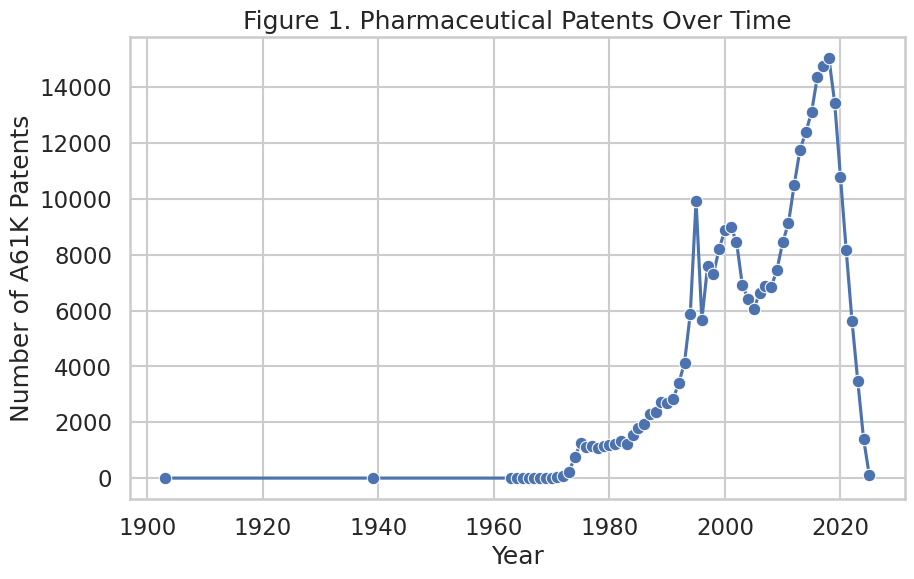

In [16]:
plt.figure()
sns.lineplot(data=yearly_patents, x="filing_year", y="patents", marker="o")
plt.title("Figure 1. Pharmaceutical Patents Over Time")
plt.xlabel("Year")
plt.ylabel("Number of A61K Patents")
plt.show()


Figure 2: Distribution of Patents Across Therapeutic Areas
This shows which therapeutic areas dominate the patent sample.

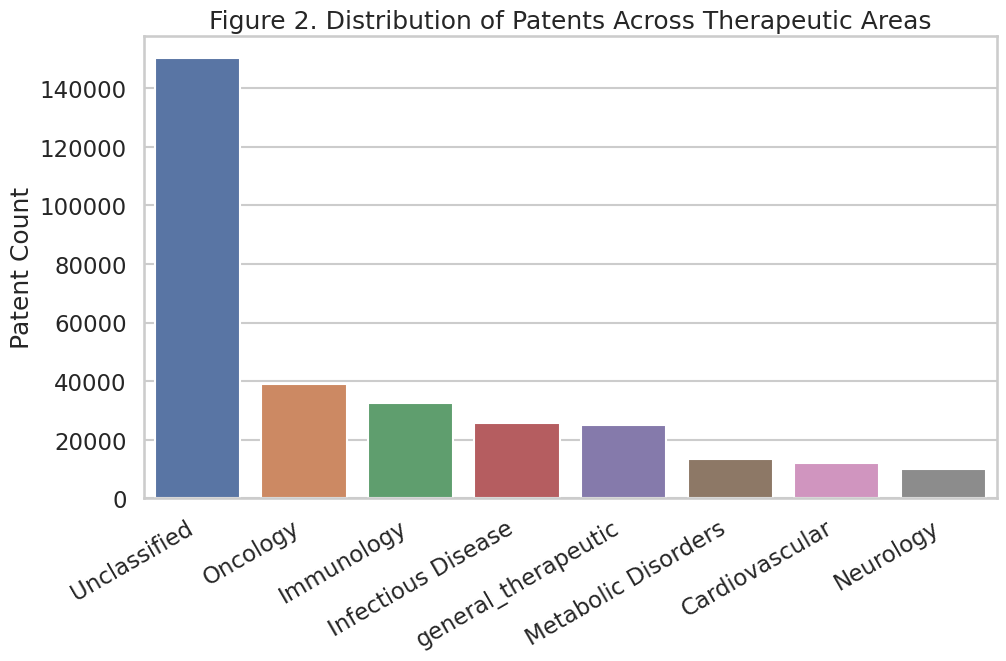

In [17]:
fig2 = area_counts.copy()
fig2["area_label"] = fig2["area"].map(AREA_LABELS).fillna(fig2["area"])
plt.figure(figsize=(11, 6))
sns.barplot(data=fig2, x="area_label", y="patents", hue="area_label", dodge=False, legend=False)
plt.title("Figure 2. Distribution of Patents Across Therapeutic Areas")
plt.xlabel("")
plt.ylabel("Patent Count")
plt.xticks(rotation=30, ha="right")
plt.show()


Figure 3: Top Patent-Producing Firms
This shows the top 10 assignees by patent count.

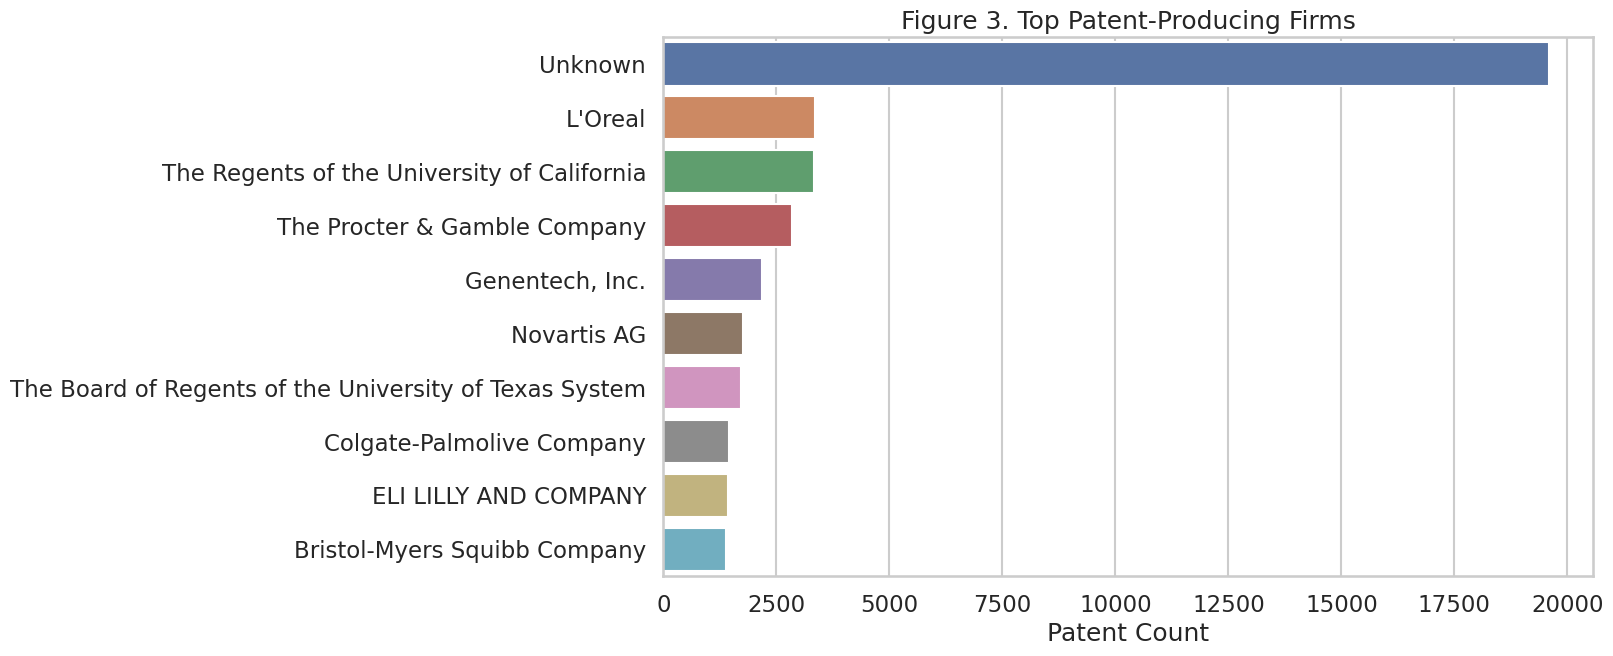

In [18]:
plt.figure(figsize=(12, 7))
sns.barplot(data=firm_counts, y="firm", x="patents", hue="firm", dodge=False, legend=False)
plt.title("Figure 3. Top Patent-Producing Firms")
plt.xlabel("Patent Count")
plt.ylabel("")
plt.show()


Figure 4: Share of AI-Related Patents Over Time
This plots AI patent share by year.

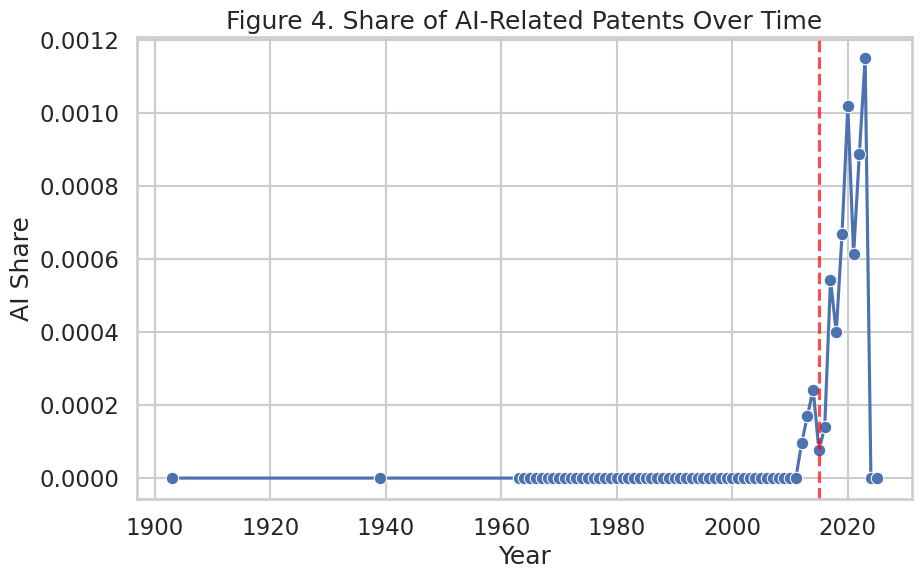

In [19]:
plt.figure()
sns.lineplot(data=yearly_ai, x="filing_year", y="AI_share", marker="o")
plt.axvline(2015, color="red", linestyle="--", alpha=0.7)
plt.title("Figure 4. Share of AI-Related Patents Over Time")
plt.xlabel("Year")
plt.ylabel("AI Share")
plt.show()


Figure 5: AI Adoption by Therapeutic Area
This compares AI adoption over time across therapeutic areas.



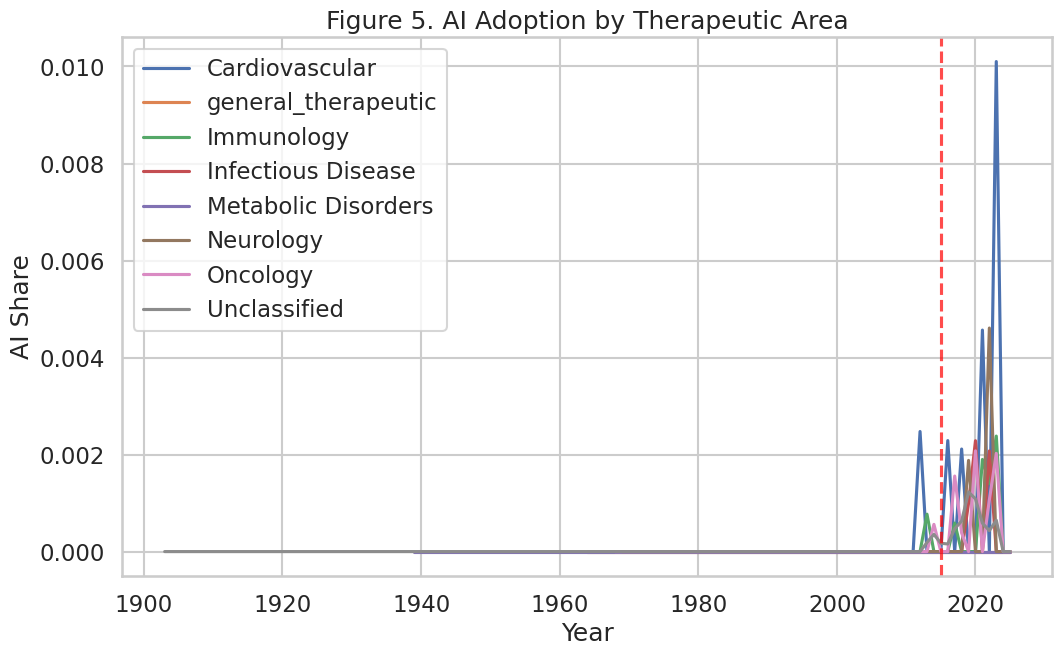

In [20]:
fig5 = panel.copy()
fig5["area_label"] = fig5["therapeutic_area"].map(AREA_LABELS).fillna(fig5["therapeutic_area"])
plt.figure(figsize=(12, 7))
sns.lineplot(data=fig5, x="year", y="AI_share", hue="area_label")
plt.axvline(2015, color="red", linestyle="--", alpha=0.7)
plt.title("Figure 5. AI Adoption by Therapeutic Area")
plt.xlabel("Year")
plt.ylabel("AI Share")
plt.legend(title="")
plt.show()


Figure 6: Heatmap of AI Exposure
This visualizes AI share by area and year.

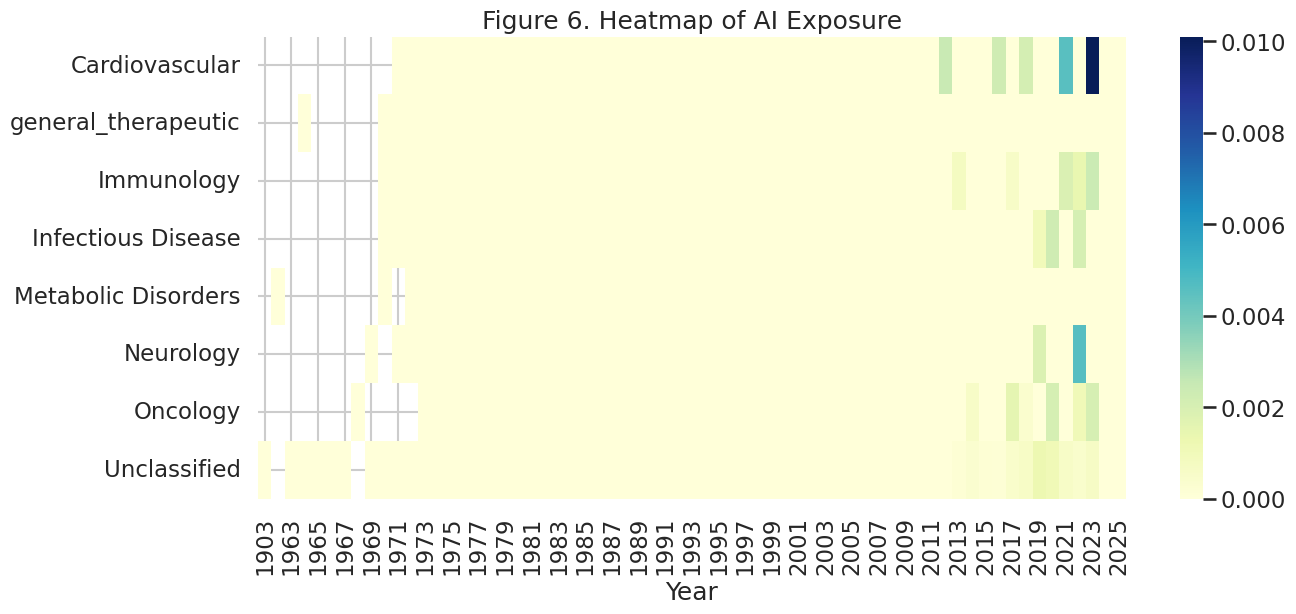

In [21]:
fig6 = panel.pivot(index="therapeutic_area", columns="year", values="AI_share").sort_index()
fig6.index = [AREA_LABELS.get(i, i) for i in fig6.index]
plt.figure(figsize=(14, 6))
sns.heatmap(fig6, cmap="YlGnBu")
plt.title("Figure 6. Heatmap of AI Exposure")
plt.xlabel("Year")
plt.ylabel("")
plt.show()


Figure 7: Target Diversity Over Time
This shows average entropy by year.

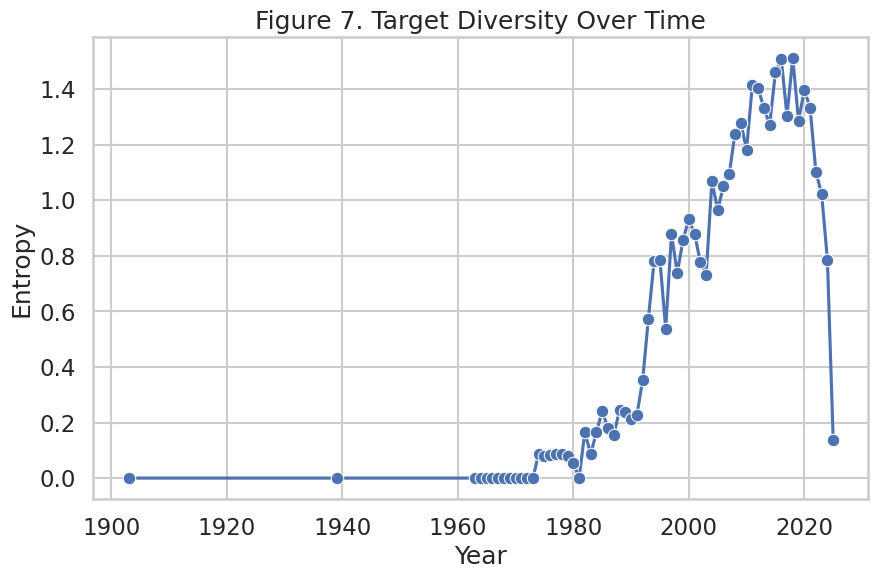

In [22]:
fig7 = panel.groupby("year")["entropy"].mean().reset_index()
plt.figure()
sns.lineplot(data=fig7, x="year", y="entropy", marker="o")
plt.title("Figure 7. Target Diversity Over Time")
plt.xlabel("Year")
plt.ylabel("Entropy")
plt.show()


Figure 8: Target Diversity by Therapeutic Area
This compares entropy trends across therapeutic areas.

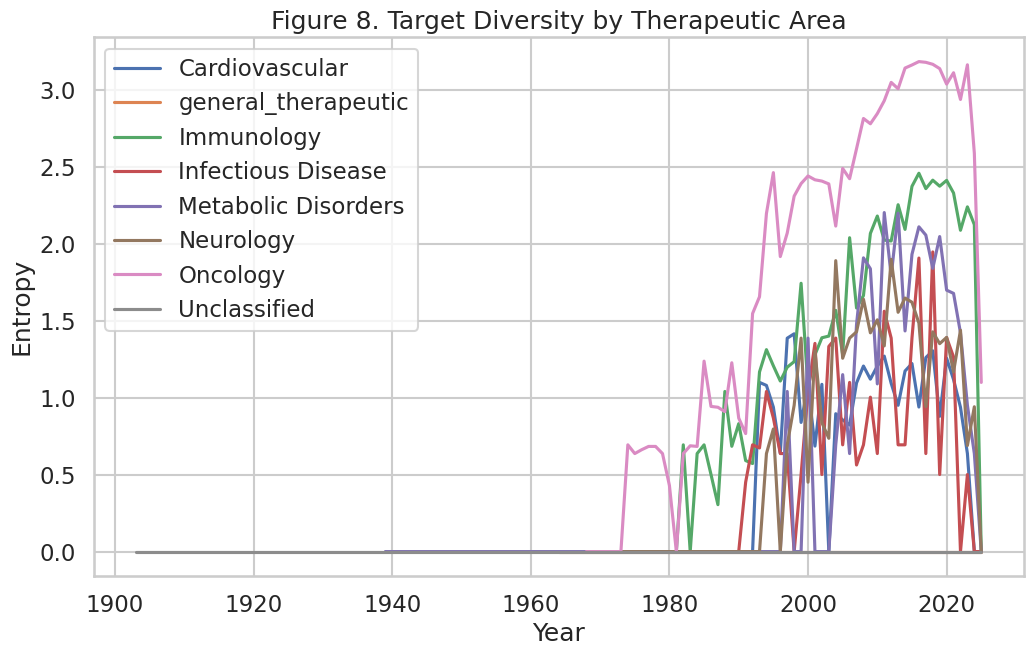

In [23]:
fig8 = panel.copy()
fig8["area_label"] = fig8["therapeutic_area"].map(AREA_LABELS).fillna(fig8["therapeutic_area"])
plt.figure(figsize=(12, 7))
sns.lineplot(data=fig8, x="year", y="entropy", hue="area_label")
plt.title("Figure 8. Target Diversity by Therapeutic Area")
plt.xlabel("Year")
plt.ylabel("Entropy")
plt.legend(title="")
plt.show()


Figure 9: Most Common Biological Targets
This shows the top biological targets by patent frequency.

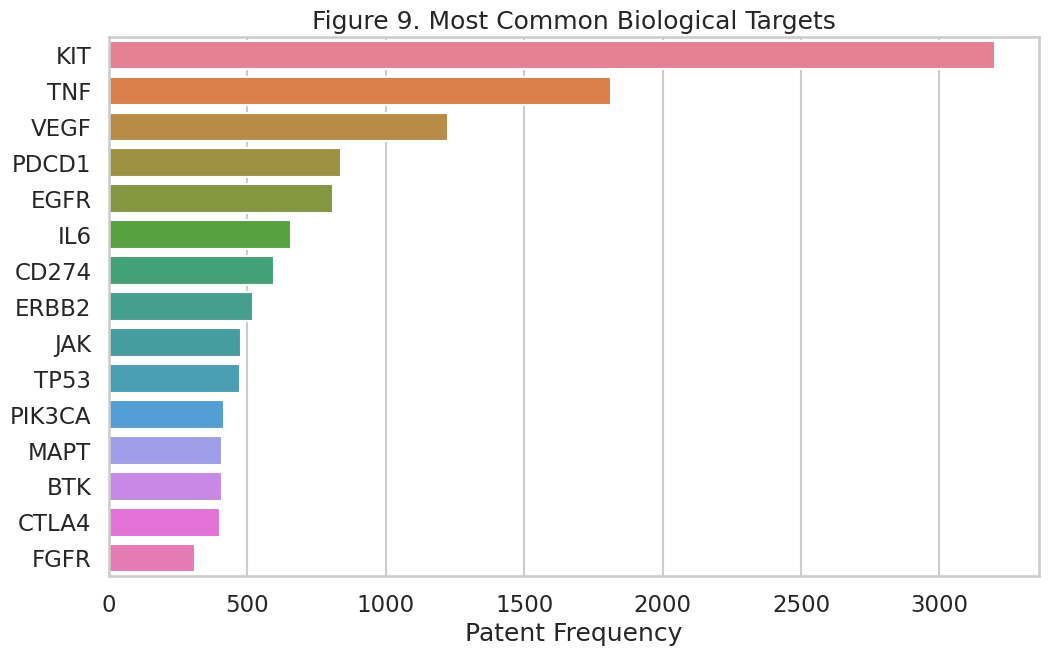

In [24]:
fig9 = patent_level[target_cols].sum().sort_values(ascending=False).head(15).reset_index()
fig9.columns = ["target", "patents"]
plt.figure(figsize=(12, 7))
sns.barplot(data=fig9, y="target", x="patents", hue="target", dodge=False, legend=False)
plt.title("Figure 9. Most Common Biological Targets")
plt.xlabel("Patent Frequency")
plt.ylabel("")
plt.show()


Figure 10: Concentration of Biological Targets
This shows how target shares evolve for the top targets.

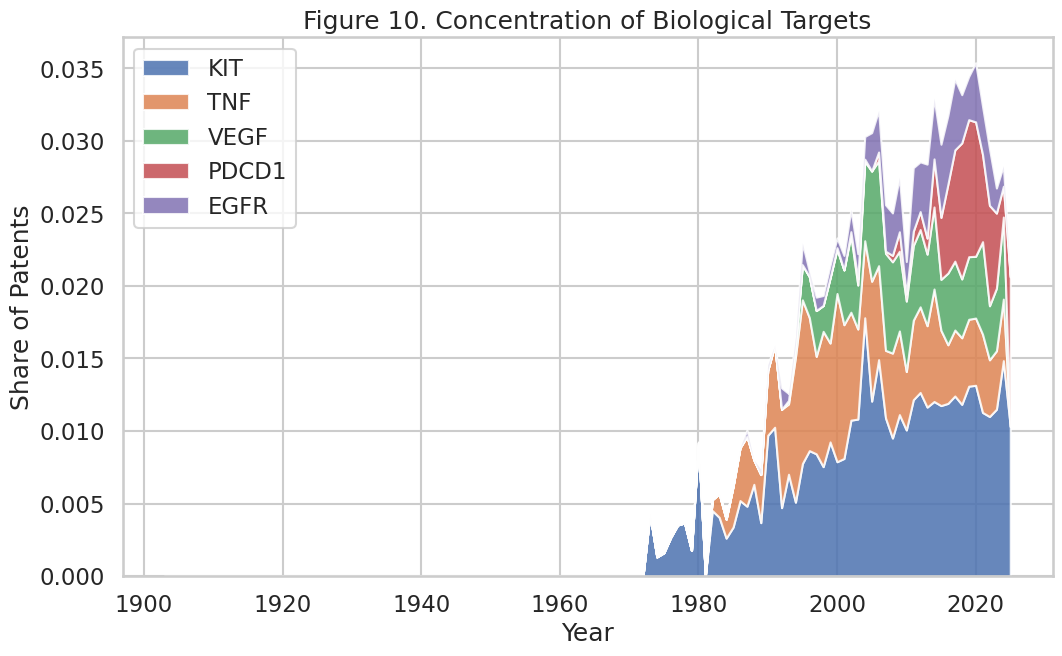

In [25]:
top_targets = patent_level[target_cols].sum().sort_values(ascending=False).head(5).index.tolist()
fig10 = patent_level.dropna(subset=["filing_year"]).groupby("filing_year")[top_targets].mean().reset_index()
plt.figure(figsize=(12, 7))
plt.stackplot(fig10["filing_year"], [fig10[t] for t in top_targets], labels=top_targets, alpha=0.85)
plt.title("Figure 10. Concentration of Biological Targets")
plt.xlabel("Year")
plt.ylabel("Share of Patents")
plt.legend(loc="upper left")
plt.show()


Figure 11: Share of Patents by Young Firms
This plots young-firm patent share over time.

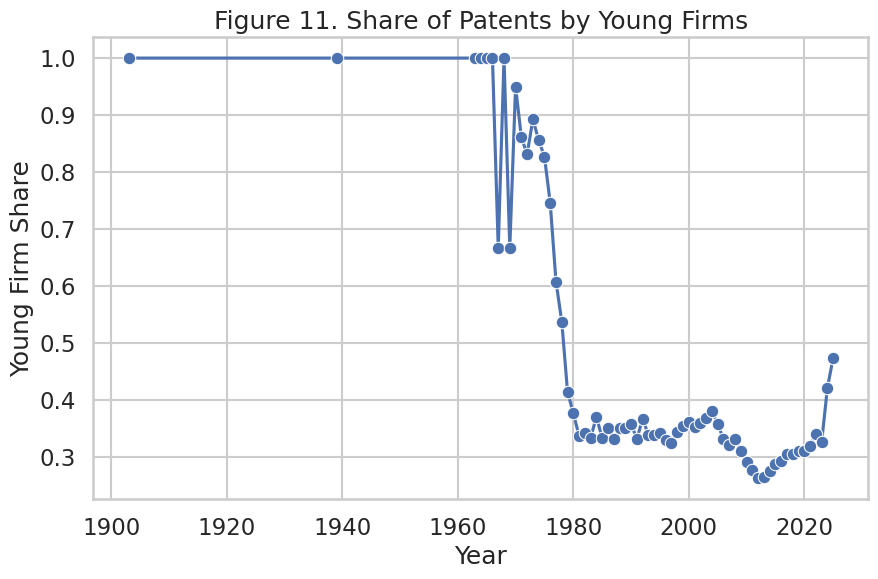

In [26]:
plt.figure()
sns.lineplot(data=yearly_young, x="filing_year", y="young_firm_share", marker="o")
plt.title("Figure 11. Share of Patents by Young Firms")
plt.xlabel("Year")
plt.ylabel("Young Firm Share")
plt.show()


Figure 12: Patent Concentration Over Time
This plots average top-4 concentration by year.

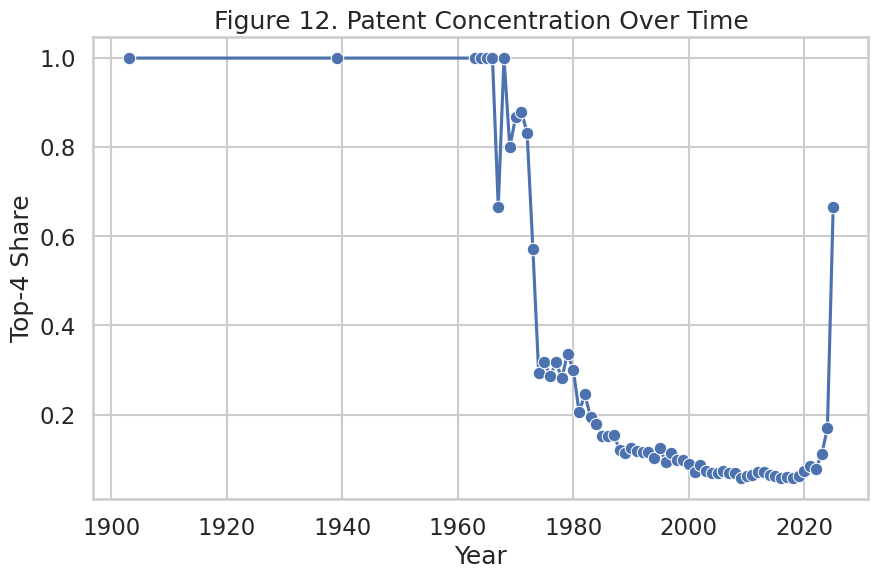

In [27]:
fig12 = panel.groupby("year")["concentration"].mean().reset_index()
plt.figure()
sns.lineplot(data=fig12, x="year", y="concentration", marker="o")
plt.title("Figure 12. Patent Concentration Over Time")
plt.xlabel("Year")
plt.ylabel("Top-4 Share")
plt.show()


Figure 13: Distribution of Firm Ages
This shows the distribution of patenting by firm age.

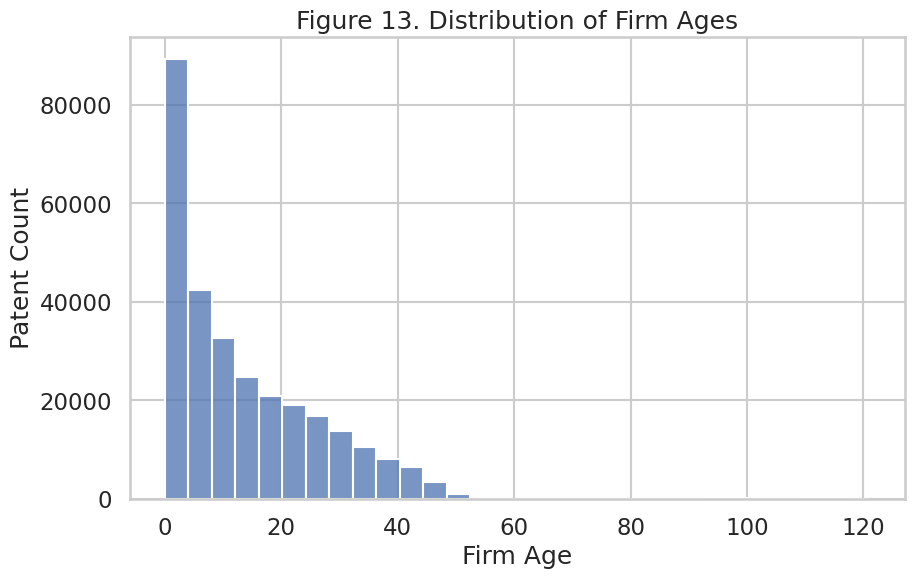

In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(patent_level["firm_age"].dropna(), bins=30)
plt.title("Figure 13. Distribution of Firm Ages")
plt.xlabel("Firm Age")
plt.ylabel("Patent Count")
plt.show()


Figure 14: Incumbent vs Young Firm Patent Shares
This compares the yearly shares of young vs incumbent firms.

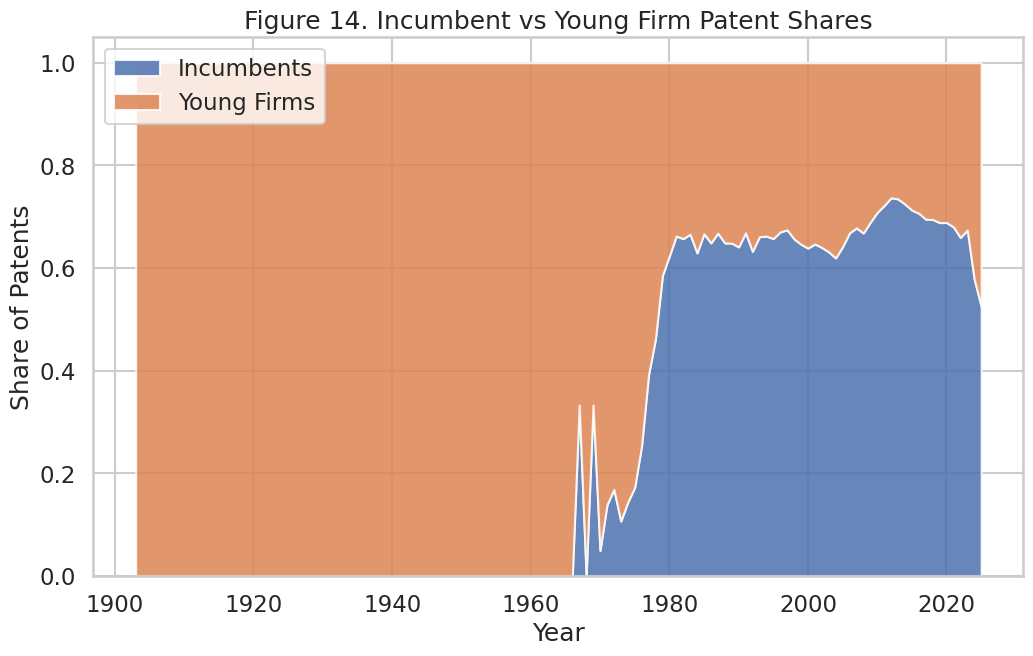

In [29]:
fig14 = patent_level.dropna(subset=["filing_year"]).copy()
fig14["firm_group"] = np.where(fig14["young_firm"] == 1, "Young Firms", "Incumbents")
fig14 = fig14.groupby(["filing_year", "firm_group"]).size().reset_index(name="n")
fig14["share"] = fig14["n"] / fig14.groupby("filing_year")["n"].transform("sum")
fig14p = fig14.pivot(index="filing_year", columns="firm_group", values="share").fillna(0)
plt.figure(figsize=(12, 7))
plt.stackplot(fig14p.index, fig14p.get("Incumbents", 0), fig14p.get("Young Firms", 0), labels=fig14p.columns, alpha=0.85)
plt.title("Figure 14. Incumbent vs Young Firm Patent Shares")
plt.xlabel("Year")
plt.ylabel("Share of Patents")
plt.legend(loc="upper left")
plt.show()


Figure 15: Entropy in High vs Low AI Areas
This is a simple visual diff-in-diff.

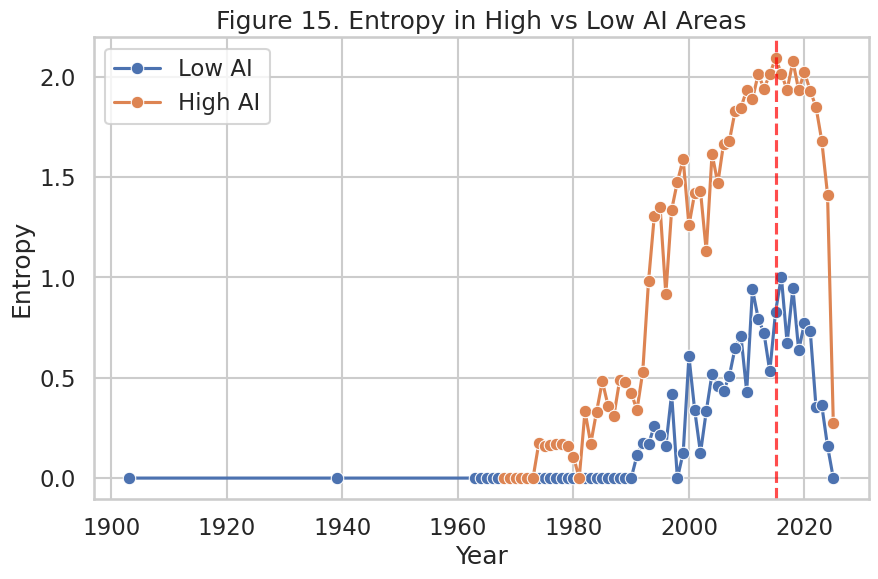

In [30]:
fig15 = panel.groupby(["year", "ai_group"])["entropy"].mean().reset_index()
plt.figure()
sns.lineplot(data=fig15, x="year", y="entropy", hue="ai_group", marker="o")
plt.axvline(2015, color="red", linestyle="--", alpha=0.7)
plt.title("Figure 15. Entropy in High vs Low AI Areas")
plt.xlabel("Year")
plt.ylabel("Entropy")
plt.legend(title="")
plt.show()


Figure 16: Event Study, AI and Target Diversity
This plots the high-minus-low entropy difference relative to 2015.

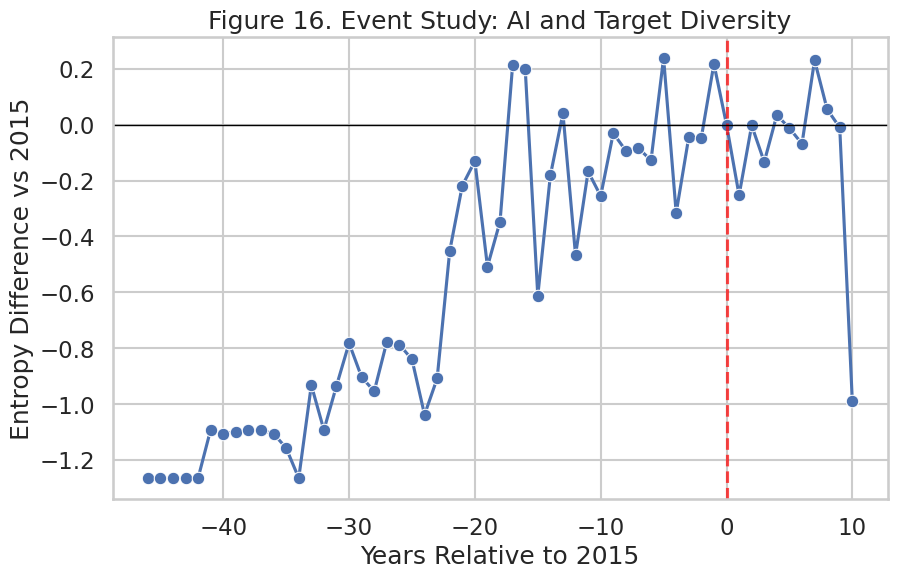

In [31]:
fig16 = panel.groupby(["year", "ai_group"])["entropy"].mean().reset_index()
fig16 = fig16.pivot(index="year", columns="ai_group", values="entropy").reset_index()
fig16["diff"] = fig16["High AI"] - fig16["Low AI"]
baseline = fig16.loc[fig16["year"] == 2015, "diff"].iloc[0]
fig16["event_time"] = fig16["year"] - 2015
fig16["diff_from_2015"] = fig16["diff"] - baseline

plt.figure()
sns.lineplot(data=fig16, x="event_time", y="diff_from_2015", marker="o")
plt.axvline(0, color="red", linestyle="--", alpha=0.7)
plt.axhline(0, color="black", linewidth=1)
plt.title("Figure 16. Event Study: AI and Target Diversity")
plt.xlabel("Years Relative to 2015")
plt.ylabel("Entropy Difference vs 2015")
plt.show()


Figure 17: Event Study, Young Firm Share
This does the same event-study style plot for young-firm share.

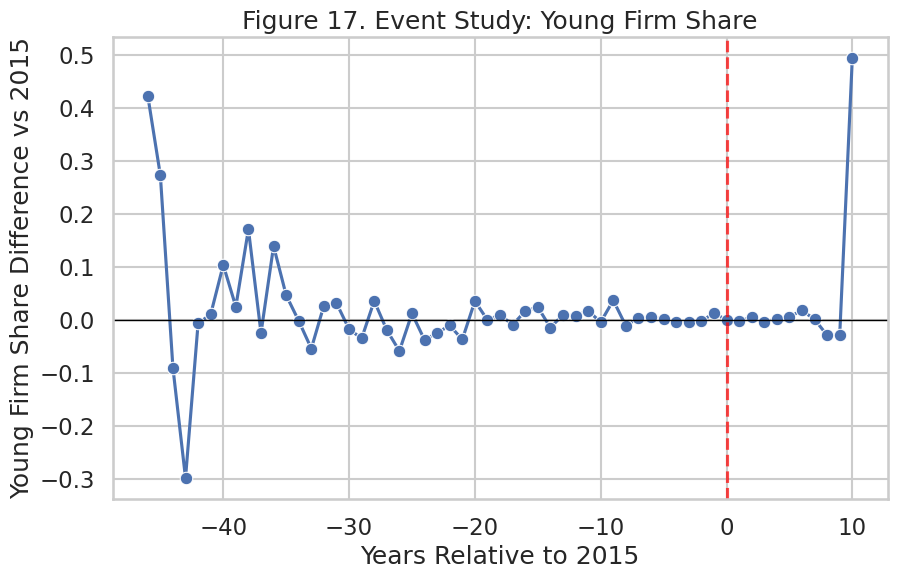

In [32]:
fig17 = panel.groupby(["year", "ai_group"])["young_firm_share"].mean().reset_index()
fig17 = fig17.pivot(index="year", columns="ai_group", values="young_firm_share").reset_index()
fig17["diff"] = fig17["High AI"] - fig17["Low AI"]
baseline = fig17.loc[fig17["year"] == 2015, "diff"].iloc[0]
fig17["event_time"] = fig17["year"] - 2015
fig17["diff_from_2015"] = fig17["diff"] - baseline

plt.figure()
sns.lineplot(data=fig17, x="event_time", y="diff_from_2015", marker="o")
plt.axvline(0, color="red", linestyle="--", alpha=0.7)
plt.axhline(0, color="black", linewidth=1)
plt.title("Figure 17. Event Study: Young Firm Share")
plt.xlabel("Years Relative to 2015")
plt.ylabel("Young Firm Share Difference vs 2015")
plt.show()


Figure 18: Event Study, Market Concentration
This does the event-study style plot for top-4 concentration.



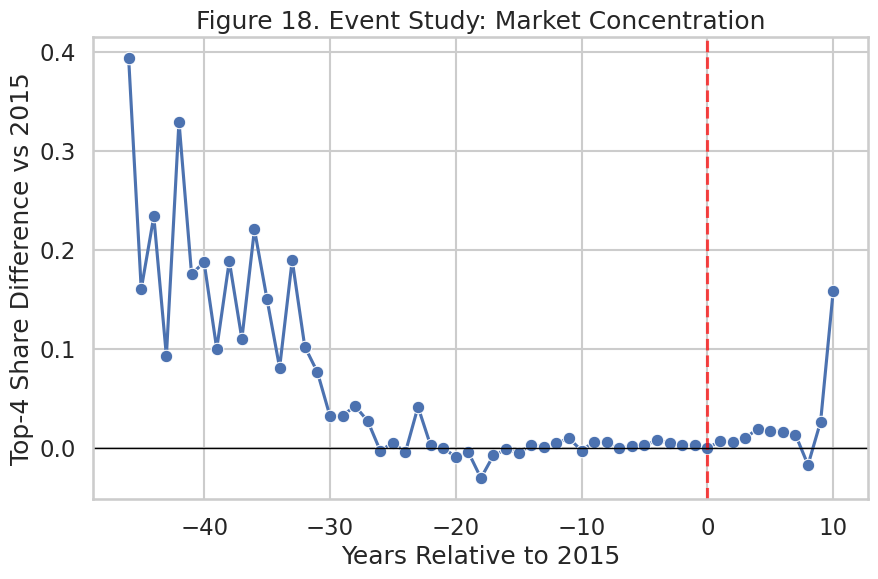

In [33]:
fig18 = panel.groupby(["year", "ai_group"])["concentration"].mean().reset_index()
fig18 = fig18.pivot(index="year", columns="ai_group", values="concentration").reset_index()
fig18["diff"] = fig18["High AI"] - fig18["Low AI"]
baseline = fig18.loc[fig18["year"] == 2015, "diff"].iloc[0]
fig18["event_time"] = fig18["year"] - 2015
fig18["diff_from_2015"] = fig18["diff"] - baseline

plt.figure()
sns.lineplot(data=fig18, x="event_time", y="diff_from_2015", marker="o")
plt.axvline(0, color="red", linestyle="--", alpha=0.7)
plt.axhline(0, color="black", linewidth=1)
plt.title("Figure 18. Event Study: Market Concentration")
plt.xlabel("Years Relative to 2015")
plt.ylabel("Top-4 Share Difference vs 2015")
plt.show()


Figure 19: Scientific Search Breadth vs Entry
This shows the cross-area-year relationship between entropy and young-firm share.

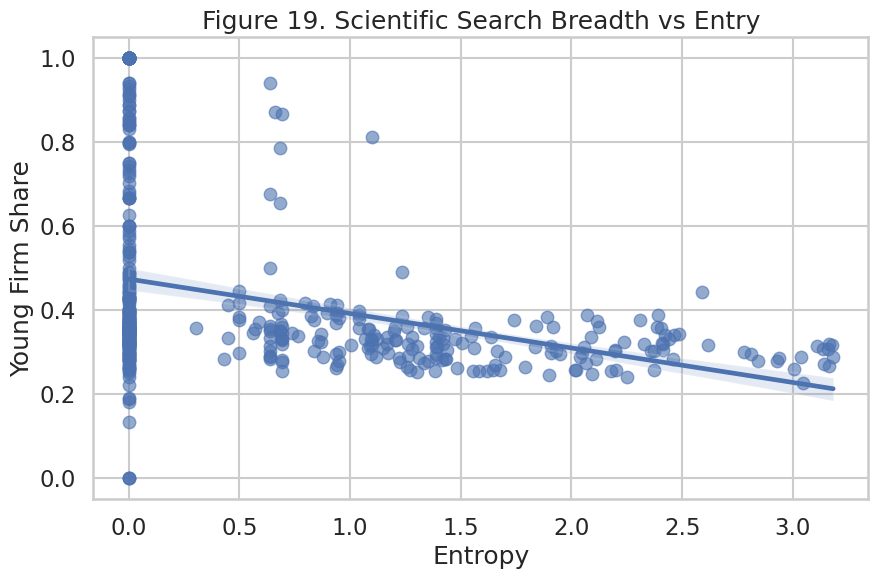

In [34]:
plt.figure()
sns.regplot(data=panel, x="entropy", y="young_firm_share", scatter_kws={"alpha": 0.6})
plt.title("Figure 19. Scientific Search Breadth vs Entry")
plt.xlabel("Entropy")
plt.ylabel("Young Firm Share")
plt.show()


Figure 20: Scientific Search Breadth vs Concentration
This shows the relationship between entropy and concentration.

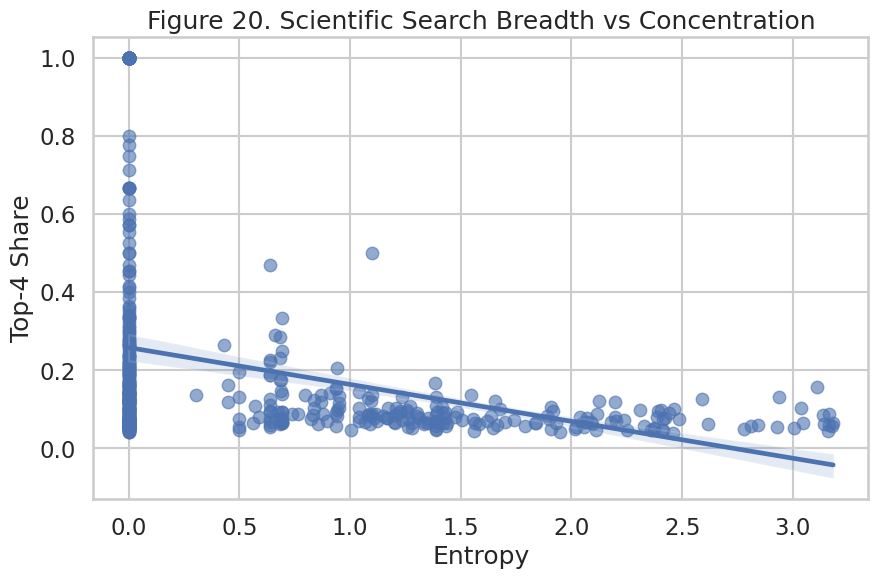

In [35]:
plt.figure()
sns.regplot(data=panel, x="entropy", y="concentration", scatter_kws={"alpha": 0.6})
plt.title("Figure 20. Scientific Search Breadth vs Concentration")
plt.xlabel("Entropy")
plt.ylabel("Top-4 Share")
plt.show()
